# 1.0 简介

- 核心观点：统计学是数据分析的基础，分为描述统计和推断统计两大分支
- 描述统计：整理、概括、描述数据特征
- 推断统计：基于样本推断总体特征，常用于市场调研和研究

# 1.1 统计学上的基本概念

## 1.1.1 总体与样本

1. 总体：研究对象的全体
2. 样本：从总体中抽取的代表性子集
3. 关键要点：
    - 样本需具有代表性（随机抽样、样本量足够）
    - 样本永远无法完全代表总体，存在抽样误差
    - 当误差在可接受范围内，可认为样本有效代表总体

## 1.1.2 参数与统计量

- 参数：描述总体的量（μ, σ², σ）
- 统计量：描述样本的量（x̄, S², S）

| 项目  | 参数（总体） | 统计量（样本） |
| --- | ------ | ------- |
| 均值  | μ      | x̄      |
| 方差  | σ²     | S²      |
| 标准差 | σ      | S       |

## 1.1.3 变量的度量范围

- 连续变量：在规定范围内可取任意值（如薪资、点击率）
- 分类变量：取值水平有限（名义变量、等级变量）
- 转换关系：实际工作中常将连续变量与分类变量相互转化

## 1.1.4 变量的分布类型

- 意义：了解分布可快速知道变量在某一取值时的概率
- 示例：城市居民与乡村居民每日步数的概率分布
- 常用分布：正态分布、均匀分布、泊松分布等（均为简化分析的假设）

## 1.1.5 正态分布

1. 特征：钟形曲线，又称高斯分布
    - 自然界常见现象：身高、体重等
2. 68-95-99.7规则：
    - 均值±1σ：68.3%数据
    - 均值±2σ：95.4%数据
    - 均值±3σ：99.7%数据
3. 应用：某变量值大于"均值+2σ"的概率为2.3%

## 1.1.6 Z分数

1. 计算公式：
    - Z = (X - μ) / σ
2. 含义：描述个体在分布中高于/低于平均数的标准差数目
3. 应用：比较不同样本间的相对位置

In [5]:
from random import sample
from types import new_class

import pandas as pd

# 读取学生调查数据
df = pd.read_excel('学生调查数据.xlsx')
df.head(5)

,编号,性别,家庭所在地区,平均月生活费
0,1,男,大型城市,800
1,2,女,中小城市,600
2,3,男,大型城市,1000
3,4,男,中小城市,400
4,5,女,中小城市,500


In [6]:
# 随机抽取一个同学，计算他的平均月生活费的Z分数
classmate = df.sample()
#个体分数：被抽中的同学的月平均月生活费
individual = classmate['平均月生活费'].values[0]
# 求解平均值和标准差，计算Z分数
mean,std = df['平均月生活费'].mean(),df['平均月生活费'].std()
z = (individual-mean)/std
result = {'个体分数：',individual,
          '样本平均值：',round(mean,3),
          '样本标准差:',round(std,3),
          '个体Z分数：',round(z,3)}

print('该同学的个人信息...')
print(result)

该同学的个人信息...
{np.float64(613.333), '个体分数：', np.float64(233.021), np.float64(-0.057), '个体Z分数：', '样本标准差:', '样本平均值：', np.int64(600)}


# 1.2 假设检验基础

## 1.2.1 假设检验的要点

**五要素：**
- 零假设（H₀）：假设"没有区别"，等号永远在此（=, ≥, ≤）
- 备择假设（H₁）：零假设不成立时被迫承认的假设
- 显著性水平（α）：通常设为0.05
- 检验统计量：如Z统计量、t统计量
- p值：零假设成立时，出现现状或更差情况的概率

p值计算示例（抛硬币）：
1. 零假设：硬币均匀，正反面概率各1/2
2. 实验：抛20次，18次正面
    - p值 = P(X≥18) = P(18)+P(19)+P(20)
    - 若p<0.05，拒绝零假设，认为有"特殊技巧"

**单侧检验 vs 双侧检验：**
- 单侧检验：有方向性（> 或 <）
- 双侧检验：无方向性（≠）

## 1.2.2 大数定理和中心极限定理

- 大数定律：样本量越大，样本均值越接近总体均值
- 中心极限定理：样本量足够大时（通常n>30），样本均值分布趋近正态分布，无论总体分布如何

# 1.3 Z分数

## 1.3.1 基本原理

1. 适用条件：
- 总体参数已知（均值μ和标准差σ）
- 大样本（n>30）
2. 检验公式：
- Z = (X̄ - μ) / (σ/√n)
3. 应用场景：检验某厂商螺钉是否符合标准（μ=3mm, σ=0.01mm）

## 1.3.2 python实现Z检验

In [7]:
df = pd.read_csv('抽检咖啡杯.csv')
df.head(5)

,抽检编号,杯子容量
0,1,11.444977
1,2,12.805967
2,3,12.449585
3,4,13.180485
4,5,12.800707


In [8]:
import math
from scipy.stats import norm #用于正态分布比较

def z_test(sample_mean,population_mean,sample_std,n,alternative='two-sided',alpha=0.05):
    '''

    :param sample_mean:
    :param population_mean:
    :param sample_std:
    :param n:
    :param alternative:
    :param alpha:
    :return:
    '''
    z = (sample_mean-population_mean)/(sample_std/math.sqrt(n))
    if alternative == 'two-sided':
        p_value = 2 * min(norm.cdf(z),1-norm.cdf(z))
    elif alternative == 'less':
        p_value = norm.cdf(z)
    elif alternative == 'greater':
        p_value = 1 - norm.cdf(z)
    else:
        raise ValueError("代替的参数必须为'two-sided','less','greater'")

    if p_value < alpha:
        print('拒绝零假设')
    else:
        print('不能拒绝零假设')
    return z,p_value

In [10]:
z_statistic,p_value = z_test(sample_mean=df['杯子容量'].mean(),
                             population_mean=12,
                             sample_std=0.4,
                             n = df.shape[0],
                             alternative='two-sided',
                             alpha=0.05)

print('z统计量为：{:.2f}'.format(z_statistic))
print('p值为：{:.4f}'.format(p_value))

不能拒绝零假设
z统计量为：-1.33
p值为：0.1842


# 1.4 t检验

## 1.4.1 单样本t检验

应用场景：检验某耳机用户评分是否达到预期值4分（样本量25<30）

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp
df = pd.read_csv('抽检耳机评分.csv')
df.head(5)

,用户编号,用户评分
0,3583,3.5
1,1347,4.6
2,5219,3.8
3,7764,2.8
4,9786,3.4


In [13]:
pop_mean = 4
sample_data = df['用户评分']#数据样本
# alternative：检验的方向，‘tow-sided’为双侧检验（默认），‘less’和‘greater’为左侧检验和右侧检验
t_stat,p_val = ttest_1samp(sample_data,pop_mean,alternative='less')
print('t统计量为：{:.2f}'.format(t_stat))
print('p值为{:.4f}'.format(p_val))

t统计量为：-1.62
p值为0.0595


结果解读：p>0.05，不拒绝零假设，认为耳机平均评分≥4分

## 1.4.2 双样本t检验

In [18]:
import numpy as np
import pandas as pd
df = pd.read_csv('改版网站购物车商品数量比较.csv',encoding='gbk')
df.sample(5)


,旧版用户编号,旧版购物车商品数,新版用户编号,新版购物车商品数
24,23,5,606,4
4,116,5,670,5
9,78,6,548,10
22,67,5,887,7
0,165,8,550,1


In [19]:
print(f'样本容量：{df.shape[0]}')
print(f"旧版用户群体的平均购物车商品数量：{df['旧版购物车商品数'].mean()},标准差：{df['旧版购物车商品数'].std()}")
print(f"新版用户群体的平均购物车商品数量：{df['新版购物车商品数'].mean()},标准差：{df['新版购物车商品数'].std()}")

样本容量：25
旧版用户群体的平均购物车商品数量：5.44,标准差：1.2609520212918492
新版用户群体的平均购物车商品数量：6.28,标准差：2.894247167514666


In [16]:
df['旧版用户编号'].isin(df['新版用户编号']).sum()

np.int64(0)

In [17]:
from scipy.stats import shapiro

# 只进行Shapiro-Wilk正态性检验
## 只需要对函数Shapiro传入一个元素大于3的数组即可
## 函数会返回统计量w和p_value
old_stat,old_p = shapiro(df['旧版购物车商品数'])
new_stat,new_p = shapiro(df['新版购物车商品数'])

print('旧版Shapiro-Wilk Test Statistic = %.3f,p_value = %.3f' % (old_stat,old_p))
print('新版Shapiro_Wilk Test Statistic = %.3f,p_value = %.3f' % (new_stat,new_p))


旧版Shapiro-Wilk Test Statistic = 0.928,p_value = 0.079
新版Shapiro_Wilk Test Statistic = 0.930,p_value = 0.087


In [20]:
from scipy.stats import levene
statistic,p_value = levene(df['旧版购物车商品数'],
                           df['新版购物车商品数'],center='median')

# center参数默认为'mean'。设置为'median'时，可以避免异常值对方差估计的影响
print('Levene’s test statistic:',statistic)
print('p-value:',p_value)

Levene’s test statistic: 13.383820998278829
p-value: 0.0006298681915368567


In [21]:
from scipy import stats

t,p = stats.ttest_ind(df['旧版购物车商品数'],df['新版购物车商品数'],equal_var=False)

# 输出结果
print('t-statistic:',t)
print('p-value:',p)

t-statistic: -1.3303757610358957
p-value: 0.19257238114301325


结果解读：p>0.05，新、旧版本购物车商品数无显著差异

# 1.5 方差分析

## 1.5.1 基本原理

应用场景：检验不同广告投放策略（A/B/C）对用户购买金额是否有显著影响

- 核心公式：
F = MSB / MSW = [SSB/(k-1)] / [SSW/(n-k)]

概念说明：
- SST：总离差平方和（总方差）
- SSB：组间离差平方和（组间差异）
- SSW：组内离差平方和（组内变异）
- k：组数（分类数）
- n：总样本量

## 1.5.2 python实现方差分析

In [22]:
df = pd.read_csv('广告投放策略.csv')
for i in ['年龄','广告投放策略']:
    print(df[i].value_counts())
    print('\n')

年龄
18-30岁    202
31-50岁    179
51岁以上     119
Name: count, dtype: int64


广告投放策略
A    169
C    166
B    165
Name: count, dtype: int64




**正态性检验：**

In [23]:
# 筛选年龄区间
users = df.query('年龄 =="18-30岁"')
strategy_A = users.query('广告投放策略 == "A" ')
strategy_B = users.query('广告投放策略 == "B" ')
strategy_C = users.query('广告投放策略 == "C" ')

from scipy.stats import shapiro
# 进行Shapiro_Walk正态性检验
a_stats,a_p = shapiro(strategy_A['用户购买金额'])
b_stats,b_p = shapiro(strategy_B['用户购买金额'])
c_stats,c_p = shapiro(strategy_C['用户购买金额'])

print('用户年龄区间：18-30岁：')
print('策略A:Shapiro_Wilk Test Statistic = %.3f,p_value = %.3f' % (a_stats,a_p))
print('策略B:Shapiro_Wilk Test Statistic = %.3f,p_value = %.3f' % (b_stats,b_p))
print('策略C:Shapiro_Walk Test Statistic = %.3f,p_value = %.3f' % (c_stats,c_p))

用户年龄区间：18-30岁：
策略A:Shapiro_Wilk Test Statistic = 0.973,p_value = 0.135
策略B:Shapiro_Wilk Test Statistic = 0.975,p_value = 0.231
策略C:Shapiro_Walk Test Statistic = 0.985,p_value = 0.553


**方差齐性检验:**

In [24]:
from scipy.stats import levene
statistic,p_value = levene(strategy_A['用户购买金额'],
                           strategy_B['用户购买金额'],
                           strategy_C['用户购买金额'])

print("Levene‘s test statistic:",statistic)
print('p-value:',p_value)

Levene‘s test statistic: 1.7474967997059323
p-value: 0.17687205059829036


In [25]:
from scipy.stats import f_oneway
f_value, p_value = f_oneway(strategy_A['用户购买金额'],
                            strategy_B['用户购买金额'],
                            strategy_C['用户购买金额'])
print('f_value:',f_value)
print('p-value:',p_value)

f_value: 348.6980183972762
p-value: 9.16512290069897e-66


结果解读：p值接近0，拒绝零假设，不同广告投放策略显著影响购买金额

# 1.6 卡方检验

应用场景：检验广告类型（A/B）是否影响用户点击率（分类变量）

In [26]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 构造数据
data = {
    'AdType': ['A'] * 100 + ['B'] * 100,
    'Click': ['Yes'] * 50 + ['No'] * 50 + ['Yes'] * 60 + ['No'] * 40,
}
df = pd.DataFrame(data)

In [27]:
df.sample(8)

,AdType,Click
182,B,No
54,A,No
167,B,No
23,A,Yes
18,A,Yes
11,A,Yes
137,B,Yes
144,B,Yes


In [28]:
# 创建列联表
cross_tab = pd.crosstab(index=df['AdType'], columns=df['Click'])
cross_tab

Click,No,Yes
AdType,,
A,50,50
B,40,60


In [29]:
import scipy.stats as stats
# 执行卡方独立性检验
chi2,p_value,_,_ = stats.chi2_contingency(cross_tab)

#打印结果
print('卡方值：',chi2)
print('p值：',p_value)

卡方值： 1.6363636363636362
p值： 0.20082512269514174


结果解读：p>0.05，广告类型与用户点击率无显著关联

# 1.7 相关分析

## 1.7.1 pearson相关系数

In [30]:
df = pd.read_csv('loan_apply.csv')
df.corr(method='pearson')

,ID,品格,能力,资本,担保,环境
ID,1.000000,-0.217816,-0.413034,-0.297205,-0.276560,-0.318641
品格,-0.217816,1.000000,0.726655,0.825342,0.676314,0.685563
能力,-0.413034,0.726655,1.000000,0.929080,0.938382,0.841413
资本,-0.297205,0.825342,0.929080,1.000000,0.883457,0.733482
担保,-0.276560,0.676314,0.938382,0.883457,1.000000,0.762563
环境,-0.318641,0.685563,0.841413,0.733482,0.762563,1.000000


## 1.7.2 热力图

### (1)基础配置

In [32]:
# 基础配置
# 基础库
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# 仅用于Jupyter Notebook
# 各种细节配置，如文字大小，图例文字等杂项
large = 22;med = 16;small=12
params = {'axes.titlesize':large,
          'legend.fontsize':med,
          'figure.figsize' : (16,10),
          'xtick.labelsize':med,
          'axes.titlesize':med,
          'ytick.labelsize':med,
          'figure.titlesize':large}

plt.rcParams.update(params)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('white')
plt.rc('font',**{'family':'Microsoft YaHei,SimHei'})
# 设置中文字体的支持
sns.set(font='SimHei')
# 解决seaborn中文显示问题，但会自动添加背景灰色网络
plt.rcParams['axes.unicode_minus'] = False
# 解决保存图像是负号'-'显示为方块的问题
# 提高输出效率库
from IPython.core.interactiveshell import InteractiveShell
# 实现notebook的多行输出
InteractiveShell.ast_node_interactive = 'all'# 默认为last

### (2)绘制热力图

<Axes: >

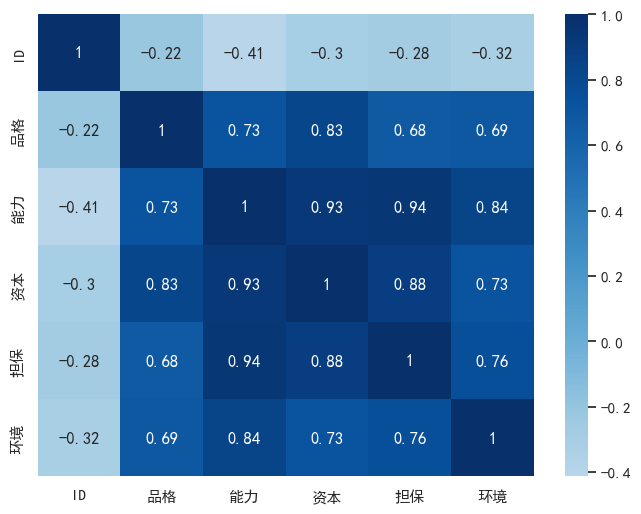

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(data = df.corr(),
            xticklabels=df.corr().columns,
            yticklabels=df.corr().columns,
            annot=True,
            cmap = 'Blues',
            center=0)

seaborn的heatmap函数参数解释：
- data：只需传入相关系数矩阵便可形成最基本的热力图。
- x/yticklabels：表示热力图横/纵坐标的标签。
- annot：True表示将相关系数值显示在颜色块上。
- cmap：热力图的颜色风格。
- center=0：表示在颜色映射中，将数值为0的颜色当成整个图像的中心颜色，颜色从该点向上和向下变化。


## 1.7.3 相关系数的显著性检验

In [34]:
import scipy.stats as stats
# 样本数据
X = [1,2,3,4,5]
Y = [5,4,3,2,1]
# 计算Pearson相关系数及其p值
r,p_value = stats.pearsonr(X,Y)
print('Pearson相关系数：',r)
print('p_value:',p_value)

Pearson相关系数： -1.0
p_value: 0.0
